In [2]:
import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

### 3: GHK voltage and current equations

default params: -67.45mV
flipped concentrations: 67.45mV
only K permeable: -93.14mV
only Na permeable: 56.03mV
only Cl permeable: 52.50mV

Jm at V=-70mV: -0.0030 A/m2
Jm at V=0mV: 0.1444 A/m2


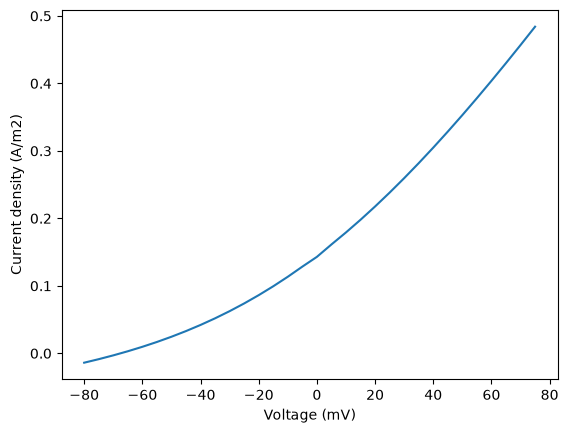

In [3]:
T = 293 # temp, kelvin
F = 96480 # faraday const, coulomb/mol
R = 8.314 # gas const, joule/kelvin/mol

@dataclass
class GHKParams:
    P_K: float = 4e-9
    Cin_K: float = 400
    Cout_K: float = 10

    P_Na: float = 0.12e-9
    Cin_Na: float = 50 
    Cout_Na: float = 460

    P_Cl: float = 0.4e-9
    Cin_Cl: float = 40 
    Cout_Cl: float = 5

def V_GHK(g: GHKParams):
    return R*T/F * math.log(
        (g.P_K*g.Cout_K + g.P_Na*g.Cout_Na + g.P_Cl*g.Cin_Cl) / 
        (g.P_K*g.Cin_K  + g.P_Na*g.Cin_Na  + g.P_Cl*g.Cout_Cl)
    )
    
g_default = GHKParams()
g_flipped = GHKParams(
    Cin_K=10, Cout_K = 400,
    Cin_Na=460, Cout_Na=50,
    Cin_Cl=5, Cout_Cl=40
)
g_only_K = GHKParams(P_K=4e-9, P_Na=0, P_Cl=0)
g_only_Na = GHKParams(P_K=0, P_Na=0.12e-9, P_Cl=0)
g_only_Cl = GHKParams(P_K=0, P_Na=0, P_Cl=0.4e-9)

print(f"default params: {V_GHK(g_default)*1000:.2f}mV") 
print(f"flipped concentrations: {V_GHK(g_flipped)*1000:.2f}mV") 
print(f"only K permeable: {V_GHK(g_only_K)*1000:.2f}mV") 
print(f"only Na permeable: {V_GHK(g_only_Na)*1000:.2f}mV") 
print(f"only Cl permeable: {V_GHK(g_only_Cl)*1000:.2f}mV") 
print()

# --- Current ---

# returns current density, A/m2
def J_GHK(P: float, Cin: float, Cout: float, z: int, V: float):
    zeta = z*V*F / (R*T)
    if V == 0: return P*z*F*(Cin - Cout)
    return P*z*F*zeta*(Cin - Cout*math.exp(-zeta)) / (1-math.exp(-zeta))

def J_GHK_total(g: GHKParams, V: float):
    I_K = J_GHK(P=g.P_K, Cin=g.Cin_K, Cout=g.Cout_K, z=1, V=V)
    I_Na = J_GHK(P=g.P_Na, Cin=g.Cin_Na, Cout=g.Cout_Na, z=1, V=V)
    I_Cl = J_GHK(P=g.P_Cl, Cin=g.Cin_Cl, Cout=g.Cout_Cl, z=-1, V=V)
    return I_K + I_Na + I_Cl

print(f"Jm at V=-70mV: {J_GHK_total(g_default, -70e-3):.4f} A/m2") 
print(f"Jm at V=0mV: {J_GHK_total(g_default, 0):.4f} A/m2")

# I-V curve
Vs = np.arange(-80e-3, 80e-3, 5e-3, dtype=float)
Js = np.array([J_GHK_total(g_default, V) for V in Vs])
plt.plot(Vs*1000, Js)
plt.xlabel("Voltage (mV)"); plt.ylabel("Current density (A/m2)");

### 4: Spherical membrane compartment

Im for 100um cell at Vm=-50.0mV: -7.71e-10A
Gm for 100um cell at Vm=-50.0mV: 4.42e-08S
Im for 1um cell at Vm=-50.0mV: -7.71e-14A
Gm for 1um cell at Vm=-50.0mV: 4.42e-12S


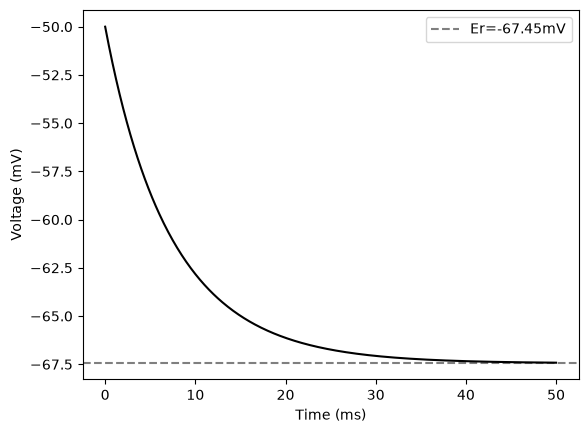

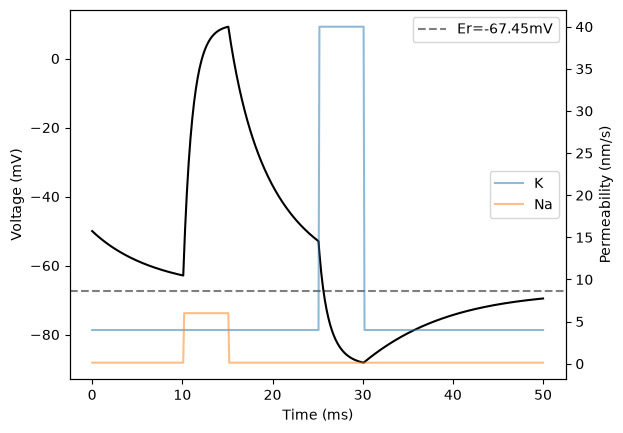

In [4]:
from collections.abc import Callable

type PermFunc = Callable[[float], float]

cm = 0.01 # specific capacitance, F/m2

def print_Im_Gm(diameter: float, Vm: float):
    area = math.pi * diameter**2

    Im_in = -1 * area * J_GHK_total(g_default, V=Vm) # negative -> outward current
    print(f"Im for {diameter*1e6:.0f}um cell at Vm={Vm*1000}mV: {Im_in:.2e}A") 

    Er = V_GHK(g_default)
    Gm = -Im_in / (Vm - Er) # chord conductance
    print(f"Gm for {diameter*1e6:.0f}um cell at Vm={Vm*1000}mV: {Gm:.2e}S")

# --- Solving Vm(t) --- 

def PNa_t_square(t: float) -> float:
    if 0.01 <= t < 0.015: return 6e-9 
    return 0.12e-9

def PK_t_square(t: float):
    if 0.025 <= t < 0.03: return 40e-9 
    return 4e-9
    
# dV/dt = I_tot(V) / Cm
def solve_ghk(g: GHKParams, diameter: float, V0: float, t_max: float=50e-3, dt: float=0.1e-3,
                  PK_t: PermFunc|None=None, PNa_t: PermFunc|None=None):
    area = math.pi * diameter**2
    Cm = cm * area
    PK_t = PK_t or (lambda t: g.P_K)
    PNa_t = PNa_t or (lambda t: g.P_Na)
    g = deepcopy(g)
    
    ts = [0.0]
    Vs = [V0]
    PKs = [PK_t(0)]
    PNas = [PNa_t(0)]
    nsteps = int(t_max / dt)
    
    for _ in range(nsteps):
        t, V = ts[-1], Vs[-1]
        g.P_K = PK_t(t)
        g.P_Na = PNa_t(t)
        
        I_ion = -area * J_GHK_total(g=g, V=V)
        dVdt = (I_ion / Cm)
        
        Vs.append(V + dVdt*dt)
        ts.append(ts[-1] + dt)
        PKs.append(g.P_K)
        PNas.append(g.P_Na)
        
    return np.array(ts), np.array(Vs), np.array(PKs), np.array(PNas)

def plot_ghk(ts, Vs, PKs=None, PNas=None):
    _, ax1 = plt.subplots()
    ax1.plot(ts*1000, Vs*1000, color="black")
    ax1.set_xlabel("Time (ms)")
    ax1.set_ylabel("Voltage (mV)")
    Er_mV = V_GHK(g_default)*1000
    ax1.axhline(Er_mV, label=f"Er={Er_mV:.2f}mV", color="k", ls="--", alpha=0.5)
    ax1.legend()

    if PKs is not None and PNas is not None:
        ax2 = ax1.twinx()
        ax2.plot(ts*1000, PKs*1e9, label="K", alpha=0.5)
        ax2.plot(ts*1000, PNas*1e9, label="Na", alpha=0.5)
        ax2.set_ylabel("Permeability (nm/s)")
        ax2.legend(loc="center right")
        
    plt.show()

diameter = 100e-6
V0 = -50e-3
print_Im_Gm(diameter=100e-6, Vm=V0) # visually 1/e -> -61mV -> ~7-8ms
print_Im_Gm(diameter=1e-6, Vm=V0) # visually 1/e -> -61mV -> ~7-8ms

ts, Vs, _, _ = solve_ghk(g=g_default, diameter=diameter, V0=V0)
plot_ghk(ts, Vs)

ts, Vs, PKs, PNas = solve_ghk(g=g_default, diameter=diameter, V0=V0, PK_t=PK_t_square, PNa_t=PNa_t_square)
plot_ghk(ts, Vs, PKs, PNas)

### 5: Stochastic, voltage-dependent ion channels

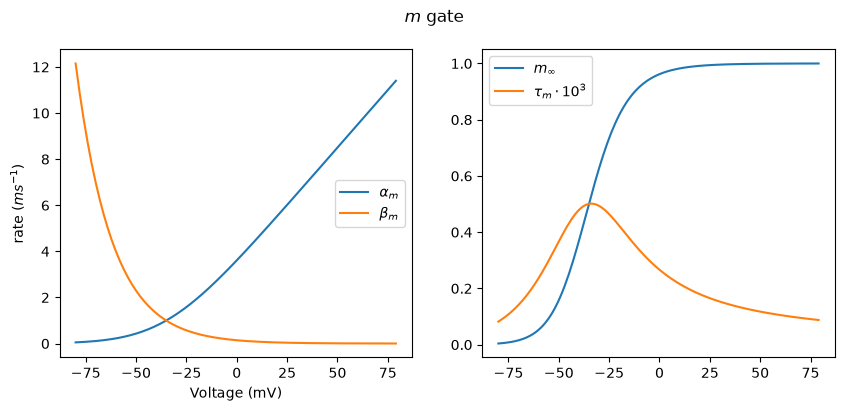

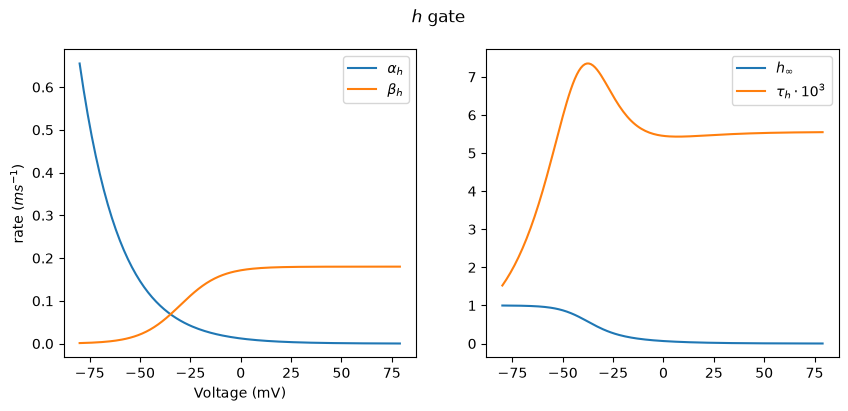

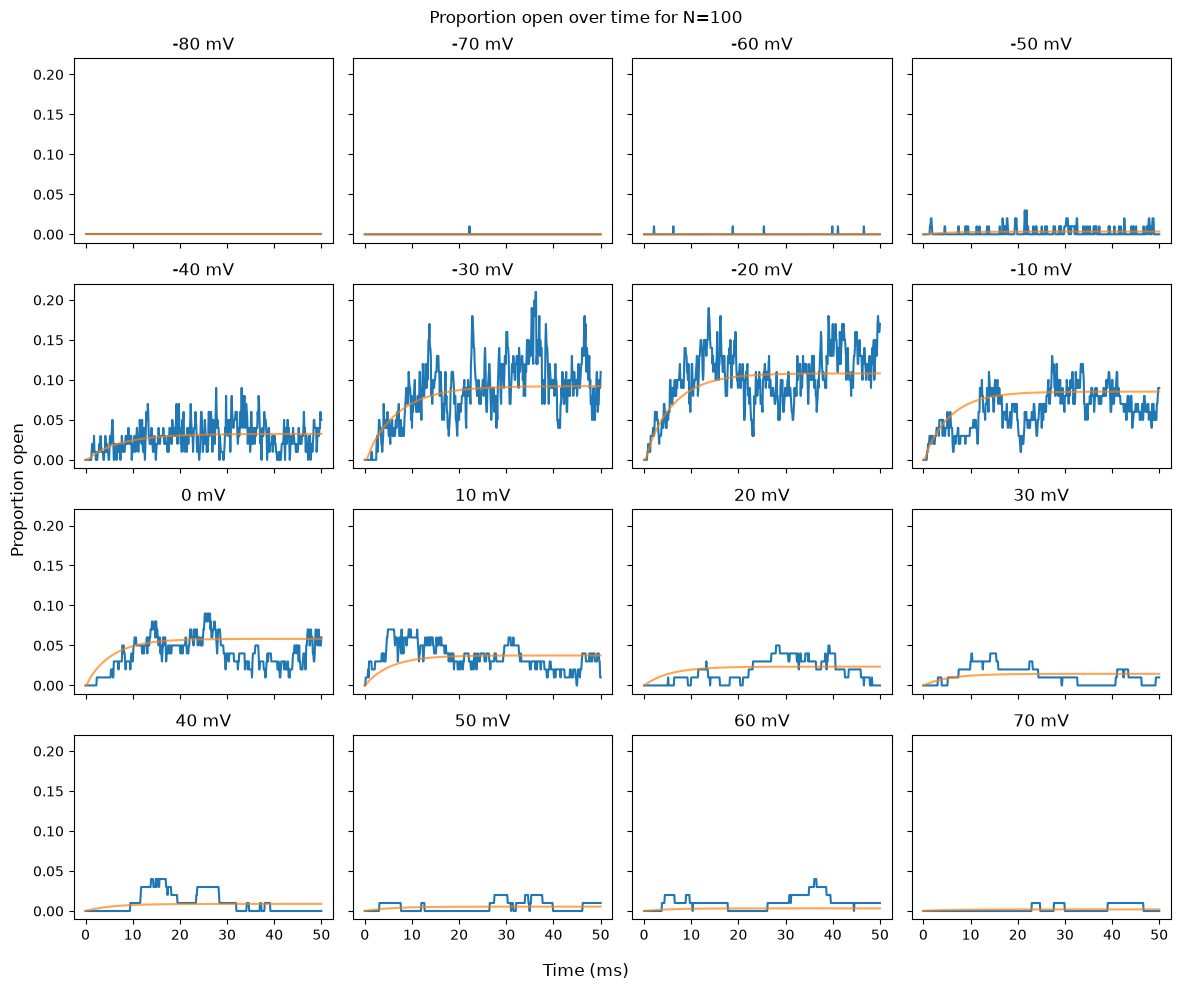

In [ ]:
@dataclass 
class GatingParticle:
    name: str
    alpha: Callable
    beta: Callable

    # states: array of 0/1, multiple particles in close(0) or open(1) states
    def next_states(self, states: np.ndarray, V: float, dt: float):
        r = np.random.random(len(states)) 
        opening = ((states == 0) & (r < self.alpha(V)*dt)).astype(int)
        closing = ((states == 1) & (r < self.beta(V)*dt)).astype(int)
        return states + opening - closing

type Channel = list[GatingParticle]

MParticle = GatingParticle("m",
    alpha = lambda V: -100_000*(V+0.035) / (np.expm1(-100*(V+0.035))),
    beta = lambda V: 4000*np.exp(-(V+0.06)/0.018)
)

HParticle = GatingParticle("h",
    alpha = lambda V: 12*np.exp(-V/0.02),
    beta = lambda V: 180 / (np.exp(-100*(V + 0.03)) + 1)
)

# as number of channels goes to infinity, they never ask for this but nice to have i think
def solve_channel_limit(channel: list[GatingParticle], V: float, 
               tmax: float=50e-3, dt: float=0.1e-3) -> tuple[list[float], list[float]]:
    ts = [0.0]
    ys = [0.0]
    yks = np.zeros(len(channel))
    nsteps = int(tmax / dt)
    for _ in range(nsteps):
        for i, particle in enumerate(channel):
            y = yks[i]
            dydt = particle.alpha(V)*(1-y) - particle.beta(V)*y 
            yks[i] += dydt * dt
        ys.append(np.prod(yks))
        ts.append(ts[-1] + dt)
    return ts, ys 

# simulate each channel stochastically
def solve_channel_stochastic(channel: Channel, V: float, N: int,
                          tmax: float=50e-3, dt: float=0.1e-3):
    ts = [0.0]
    num_particles = len(channel)
    states = np.zeros((N, num_particles)) # each row is one channel, containg K independent particles
    ys = [0.0] # fraction of channels in the open state 
    nsteps = int(tmax / dt)
    for _ in range(nsteps):
        for i, particle in enumerate(channel): # update each particle using its alpha and beta
            states[:, i] = particle.next_states(states[:, i], V=V, dt=dt)
        
        y = states.all(axis=1).mean() # one channel (row) is open iff all particles (columns) are open
        ys.append(y)
        ts.append(ts[-1] + dt)
        
    return np.array(ts), np.array(ys)

def plot_alpha_beta(particle: GatingParticle):
    Vs = np.arange(-80e-3, 80e-3, 1e-3)
    alphas, betas = particle.alpha(Vs), particle.beta(Vs)
    inf = alphas / (alphas + betas)
    tau = 1 / (alphas + betas)
    
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 4))
    fig.suptitle(f"${particle.name}$ gate")
    
    ax1.plot(Vs*1000, alphas/1000, label=fr"$\alpha_{particle.name}$")
    ax1.plot(Vs*1000, betas/1000, label=fr"$\beta_{particle.name}$")
    ax1.set_xlabel("Voltage (mV)"); ax1.set_ylabel("rate $(ms^{-1})$")
    ax1.legend()
    
    ax2.plot(Vs*1000, inf, label=fr"${particle.name}_\infty$")
    ax2.plot(Vs*1000, tau*1000, label=fr"$\tau_{particle.name} \cdot 10^3$")
    ax1.set_xlabel("Voltage (mV)");
    ax2.legend()
    plt.show()

plot_alpha_beta(MParticle)
plot_alpha_beta(HParticle)

Vs = np.arange(-80, 71, 10) * 1e-3

# channel = [MParticle]
channel = [MParticle]*3 + [HParticle]
num_channels = 100

fig, axs = plt.subplots(4, 4, figsize=(12, 10), sharex=True, sharey=True)
for ax, V in zip(axs.flat, Vs):
    ts, ys = solve_channel_stochastic(channel, V=V, N=num_channels)
    _, ys_limit = solve_channel_limit(channel, V=V)
    ax.plot(ts*1000, ys)
    ax.plot(ts*1000, ys_limit, alpha=0.7)
    ax.set_title(f"{V*1000:.0f} mV")
fig.suptitle(f"Proportion open over time for N={num_channels}")
fig.supxlabel("Time (ms)")
fig.supylabel("Proportion open")
plt.tight_layout()
plt.show()

### 6: GHK with voltage-dependent channels

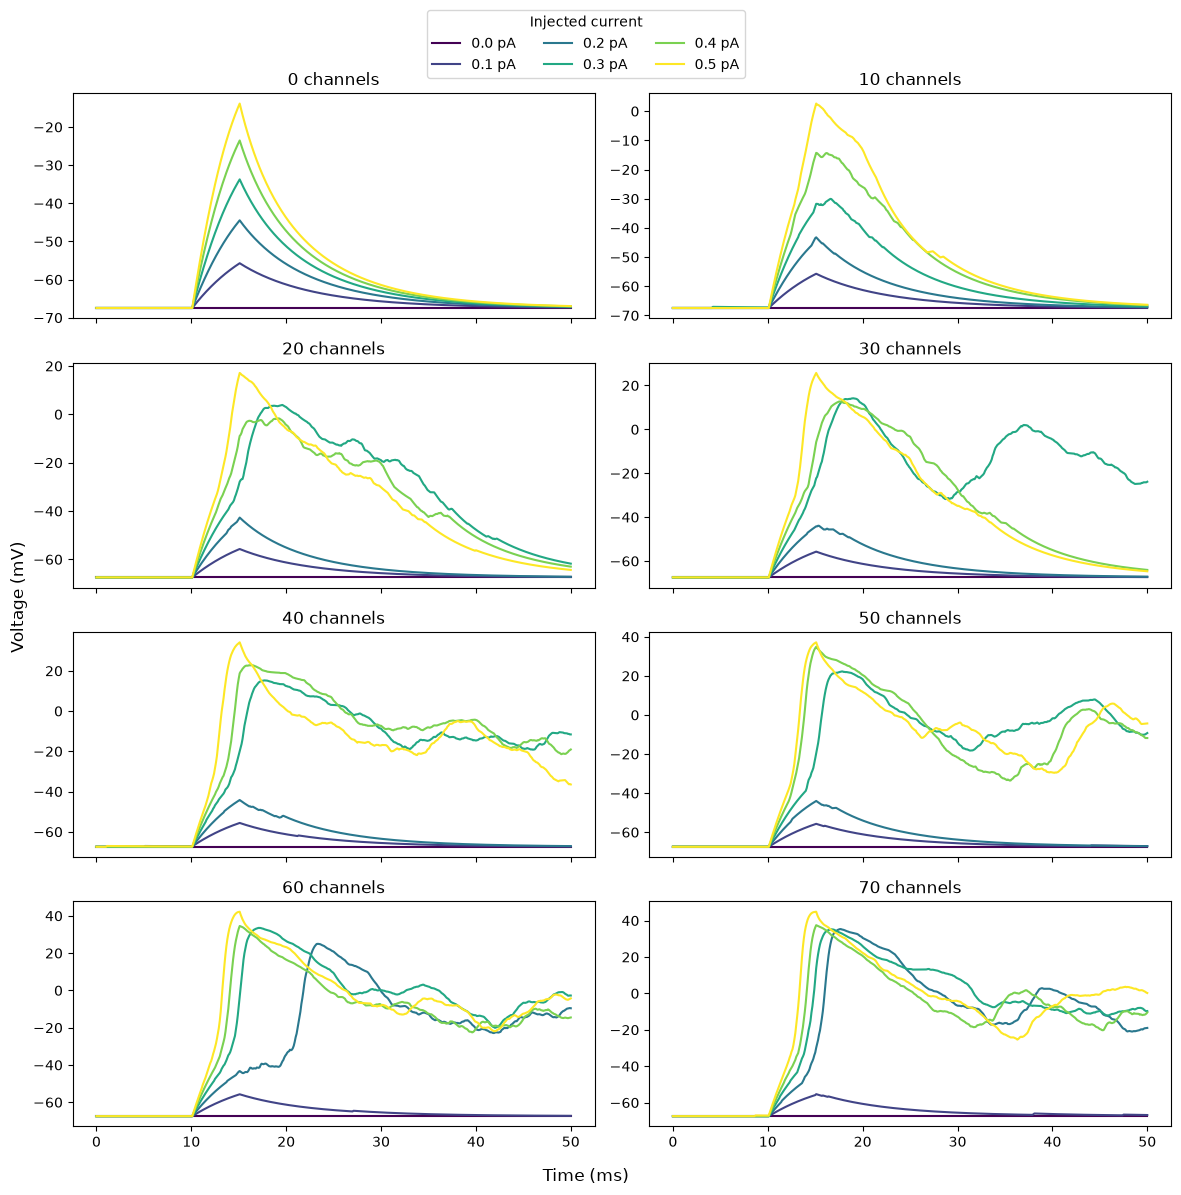

In [ ]:
def I_injected(t: float, peak: float):
    return peak if 10e-3 < t < 15e-3 else 0

def PK_t(t: float) -> float:
    if 0.02 <= t < 0.025: return 40e-9 
    return 4e-9 

GNa_max = 1e-12  # 1pS (siemens?)

# dV/dt = I_tot(V) / Cm
def solve_ghk_with_ion_channels(
    g: GHKParams, diameter: float, V0: float, 
    peak_injected: float, num_na_channels: int,
    t_max: float=50e-3, dt: float=0.1e-3,
    PK_t: PermFunc|None=None, PNa_t: PermFunc|None=None
):
    area = math.pi * diameter**2
    Cm = cm * area
    g = deepcopy(g)
    PK_t = PK_t if PK_t is not None else lambda t: g.P_K
    
    na_channel = [MParticle]*3 + [HParticle]
    na_channels_states = np.zeros((num_na_channels, len(na_channel))) # 4 gating particles per channel
    E_Na = 56.03e-3
    
    ts = [0.0]
    Vs = [V0]
    I_Nas, I_injs = [0.0], [0.0]
    nsteps = int(t_max / dt)
    for _ in range(nsteps):
        t, V = ts[-1], Vs[-1]
        g.P_K = PK_t(t)
        
        for i, particle in enumerate(na_channel):
            na_channels_states[:, i] = particle.next_states(na_channels_states[:, i], V=V, dt=dt)
        num_na_open = na_channels_states.all(axis=1).sum() # channel open if all particles open
        G_Na = num_na_open * GNa_max
        I_Na = G_Na * (V - E_Na)
        
        I_inj = I_injected(t, peak_injected)
        
        # positive inward (since membrane voltage increases on inward current)
        I_tot = (
            I_inj    
            -area*(J_GHK_total(g=g, V=V))  # leak flow (capacitor), negate since ghk assumed positive outward
            -I_Na                          # ion channel (conductor), also negate
        )
        dVdt = (I_tot / Cm)
        
        ts.append(t + dt)
        Vs.append(V + dVdt*dt)
        I_Nas.append(-G_Na * (V - E_Na))
        I_injs.append(I_injected(t, peak_injected))
        
    return np.array(ts), np.array(Vs), np.array(I_Nas), np.array(I_injs)

channel_range = np.arange(0, 71, 10)
injected_range = np.arange(0, 0.51, 0.1) * 1e-12
colors = plt.cm.viridis(np.linspace(0, 1, len(injected_range)))
peak_Vs = np.zeros((len(injected_range), len(channel_range)))

ncols = 2
nrows = math.ceil(len(channel_range) / ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 3*nrows), sharex=True)
for i, num_channels in enumerate(channel_range):
    ax = axs.flat[i]
    for j, peak_injected in enumerate(injected_range):
        ts, Vs, _, _ = solve_ghk_with_ion_channels(
            g=g_default, diameter=1e-6, V0=V_GHK(g_default),
            t_max=50e-3, dt=0.1e-3,
            peak_injected=peak_injected, num_na_channels=int(num_channels),
            # PK_t=PK_t,
        )
        peak_Vs[j, i] = Vs.max()
        ax.plot(ts*1000, Vs*1000, color=colors[j], label=f"{peak_injected*1e12:.1f} pA")
        
    ax.set_title(f"{num_channels} channels")

for ax in axs.flat[len(channel_range):]:
    ax.remove()

fig.supxlabel("Time (ms)")
fig.supylabel("Voltage (mV)")
handles, labels = axs.flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Injected current", loc="upper center",
    bbox_to_anchor=(0.5, 0.995), ncol=3,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

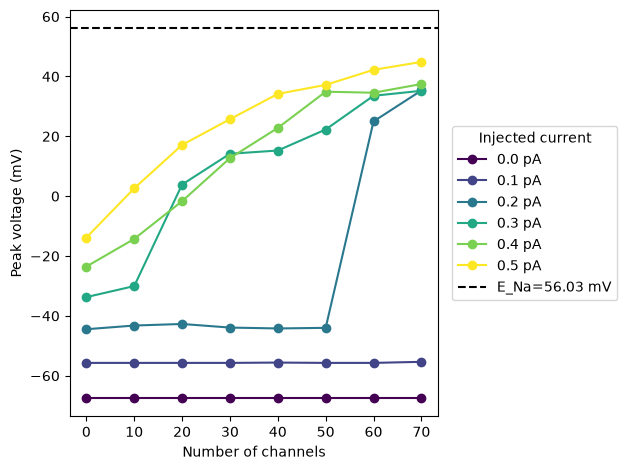

In [11]:
fig, ax = plt.subplots()
for j, peak_injected in enumerate(injected_range):
    ax.plot(
        channel_range, peak_Vs[j]*1000, marker="o", color=colors[j],
        label=f"{peak_injected*1e12:.1f} pA",
    )
ax.set_xlabel("Number of channels")
ax.set_ylabel("Peak voltage (mV)")
ax.axhline(56.03, label="E_Na=56.03 mV", color="k", ls="--")
ax.legend(title="Injected current", loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show();